In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
plt.style.use('ggplot')

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)

pd.options.mode.chained_assignment = None

##### Загрузка данных

In [3]:
horse_colic = fetch_ucirepo(id=47)

X = horse_colic.data.features.copy()
y = horse_colic.data.targets.copy()

df = pd.concat([X, y], axis=1)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

target_col = y.columns[0]
target_col = target_col.strip().lower().replace('-', '_').replace(' ', '_')

print(df)

     surgery  age  hospital_number  rectal_temperature  pulse  \
0        2.0    1           530101                38.5   66.0   
1        1.0    1           534817                39.2   88.0   
2        2.0    1           530334                38.3   40.0   
3        1.0    9          5290409                39.1  164.0   
4        2.0    1           530255                37.3  104.0   
..       ...  ...              ...                 ...    ...   
363      2.0    1           529695                38.6   60.0   
364      2.0    1           528452                37.8   42.0   
365      1.0    1           534783                38.0   60.0   
366      2.0    1           528926                38.0   42.0   
367      2.0    1           530670                37.6   88.0   

     respiratory_rate  temperature_of_extremities  peripheral_pulse  \
0                28.0                         3.0               3.0   
1                20.0                         NaN               NaN   
2     

In [4]:
print(df.shape)
print(df.dtypes)

(368, 28)
surgery                           float64
age                                 int64
hospital_number                     int64
rectal_temperature                float64
pulse                             float64
respiratory_rate                  float64
temperature_of_extremities        float64
peripheral_pulse                  float64
mucous_membranes                  float64
capillary_refill_time             float64
pain                              float64
peristalsis                       float64
abdominal_distension              float64
nasogastric_tube                  float64
nasogastric_reflux                float64
nasogastric_reflux_ph             float64
rectal_examination_feces          float64
abdomen                           float64
packed_cell_volume                float64
total_protein                     float64
abdominocentesis_appearance       float64
abdominocentesis_total_protein    float64
outcome                           float64
lesion_site             

In [5]:
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
print(numeric_cols)

['surgery' 'age' 'hospital_number' 'rectal_temperature' 'pulse'
 'respiratory_rate' 'temperature_of_extremities' 'peripheral_pulse'
 'mucous_membranes' 'capillary_refill_time' 'pain' 'peristalsis'
 'abdominal_distension' 'nasogastric_tube' 'nasogastric_reflux'
 'nasogastric_reflux_ph' 'rectal_examination_feces' 'abdomen'
 'packed_cell_volume' 'total_protein' 'abdominocentesis_appearance'
 'abdominocentesis_total_protein' 'outcome' 'lesion_site' 'lesion_type'
 'lesion_subtype' 'cp_data' 'surgical_lesion']


In [6]:
df_non_numeric = df.select_dtypes(exclude=[np.number])
non_numeric_cols = df_non_numeric.columns.values
print(non_numeric_cols)

[]


### Исследование целевой переменной

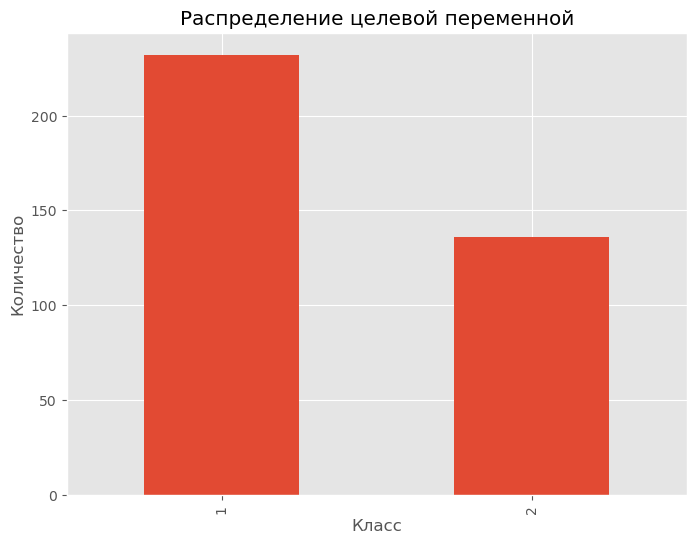

surgical_lesion
1    232
2    136
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(8, 6))
df[target_col].value_counts().plot(kind='bar')
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.title('Распределение целевой переменной')
plt.show()

print(df[target_col].value_counts())

### Отсутствующие данные

In [8]:
print(df.describe(include='all'))

          surgery         age  hospital_number  rectal_temperature  \
count  366.000000  368.000000     3.680000e+02          299.000000   
mean     1.415301    1.608696     1.112334e+06           38.134448   
std      0.493448    2.123985     1.560122e+06            0.711684   
min      1.000000    1.000000     5.142790e+05           35.400000   
25%      1.000000    1.000000     5.289152e+05           37.800000   
50%      1.000000    1.000000     5.302990e+05           38.100000   
75%      2.000000    1.000000     5.347275e+05           38.500000   
max      2.000000    9.000000     5.305629e+06           40.800000   

            pulse  respiratory_rate  temperature_of_extremities  \
count  342.000000        297.000000                  303.000000   
mean    70.757310         30.521886                    2.356436   
std     28.089867         17.669651                    1.041371   
min     30.000000          8.000000                    1.000000   
25%     48.000000         18.00000

In [9]:
df_new = df.replace(['?', '', ' ', 'NA', 'N/A', 'nan', 'NaN'], np.nan)

print('Количество строк:', df_new.shape[0])
print('Пропущенные данные по столбцам:')
print(df_new.isnull().sum())

Количество строк: 368
Пропущенные данные по столбцам:
surgery                             2
age                                 0
hospital_number                     0
rectal_temperature                 69
pulse                              26
respiratory_rate                   71
temperature_of_extremities         65
peripheral_pulse                   83
mucous_membranes                   48
capillary_refill_time              38
pain                               63
peristalsis                        52
abdominal_distension               65
nasogastric_tube                  131
nasogastric_reflux                133
nasogastric_reflux_ph             299
rectal_examination_feces          128
abdomen                           143
packed_cell_volume                 37
total_protein                      43
abdominocentesis_appearance       194
abdominocentesis_total_protein    235
outcome                             2
lesion_site                         0
lesion_type                       

### Приведение категориальных данных к единому формату

In [10]:
cat_cols = df_new.select_dtypes(exclude=[np.number]).columns

for col in cat_cols:
    df_new[col] = df_new[col].astype(str).str.strip().str.lower()

for col in df_new.columns:
    print(df_new[col].value_counts(dropna=False))
    print()

surgery
1.0    214
2.0    152
NaN      2
Name: count, dtype: int64

age
1    340
9     28
Name: count, dtype: int64

hospital_number
528151     2
5274919    2
527916     2
529424     2
529461     2
          ..
529840     1
530360     1
534579     1
534556     1
534783     1
Name: count, Length: 346, dtype: int64

rectal_temperature
NaN     69
38.0    34
38.3    23
38.2    23
38.5    21
37.8    21
37.5    16
38.1    15
38.4    14
38.6    14
37.7    10
37.6    10
37.9     9
38.7     9
37.2     7
37.3     6
38.8     6
39.0     6
39.2     5
37.1     5
39.3     4
38.9     4
37.4     4
37.0     4
39.5     4
39.4     3
39.1     3
40.3     2
39.7     2
36.6     2
36.5     2
36.0     2
36.9     1
40.8     1
36.1     1
35.4     1
36.8     1
39.6     1
36.4     1
39.9     1
40.0     1
Name: count, dtype: int64

pulse
48.0     35
60.0     33
NaN      26
40.0     21
44.0     16
88.0     15
42.0     15
52.0     14
100.0    13
72.0     13
120.0    12
84.0     11
80.0     11
54.0      9
56.0      9
9

### Дубликаты записей

In [11]:
df_drop = df_new.drop_duplicates()

print('До удаления дубликатов:', df_new.shape)
print('После удаления дубликатов:', df_drop.shape)

df_drop.head()

До удаления дубликатов: (368, 28)
После удаления дубликатов: (368, 28)


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


### Кодирование категориальных признаков

In [12]:
df_encoded = df_drop.copy()
encoders = {}

for col in df_encoded.columns:
    labelencoder = LabelEncoder()
    df_encoded[col] = labelencoder.fit_transform(df_encoded[col])
    encoders[col] = dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_)))

print('Словари кодирования:')
for col, mapping in encoders.items():
    print(col, mapping)

df_encoded.head()

Словари кодирования:
surgery {np.float64(1.0): np.int64(0), np.float64(2.0): np.int64(1), np.float64(nan): np.int64(2)}
age {np.int64(1): np.int64(0), np.int64(9): np.int64(1)}
hospital_number {np.int64(514279): np.int64(0), np.int64(518476): np.int64(1), np.int64(521399): np.int64(2), np.int64(521681): np.int64(3), np.int64(522979): np.int64(4), np.int64(523190): np.int64(5), np.int64(526090): np.int64(6), np.int64(526639): np.int64(7), np.int64(526802): np.int64(8), np.int64(527365): np.int64(9), np.int64(527463): np.int64(10), np.int64(527465): np.int64(11), np.int64(527494): np.int64(12), np.int64(527518): np.int64(13), np.int64(527524): np.int64(14), np.int64(527544): np.int64(15), np.int64(527563): np.int64(16), np.int64(527642): np.int64(17), np.int64(527664): np.int64(18), np.int64(527677): np.int64(19), np.int64(527698): np.int64(20), np.int64(527702): np.int64(21), np.int64(527706): np.int64(22), np.int64(527709): np.int64(23), np.int64(527734): np.int64(24), np.int64(527758)

,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,1,0,157,23,19,16,2,2,6,1,...,24,37,3,44,1,57,0,0,1,1
1,0,0,264,30,30,9,4,4,3,0,...,29,81,1,9,2,13,0,0,1,1
2,1,0,173,21,4,13,0,0,2,0,...,11,20,3,44,0,0,0,0,0,1
3,0,1,326,29,52,36,3,0,5,1,...,27,25,2,34,1,13,0,0,0,0
4,1,0,166,11,36,20,4,4,5,1,...,52,27,3,44,1,36,0,0,1,1


## Нетипичные данные (выбросы)

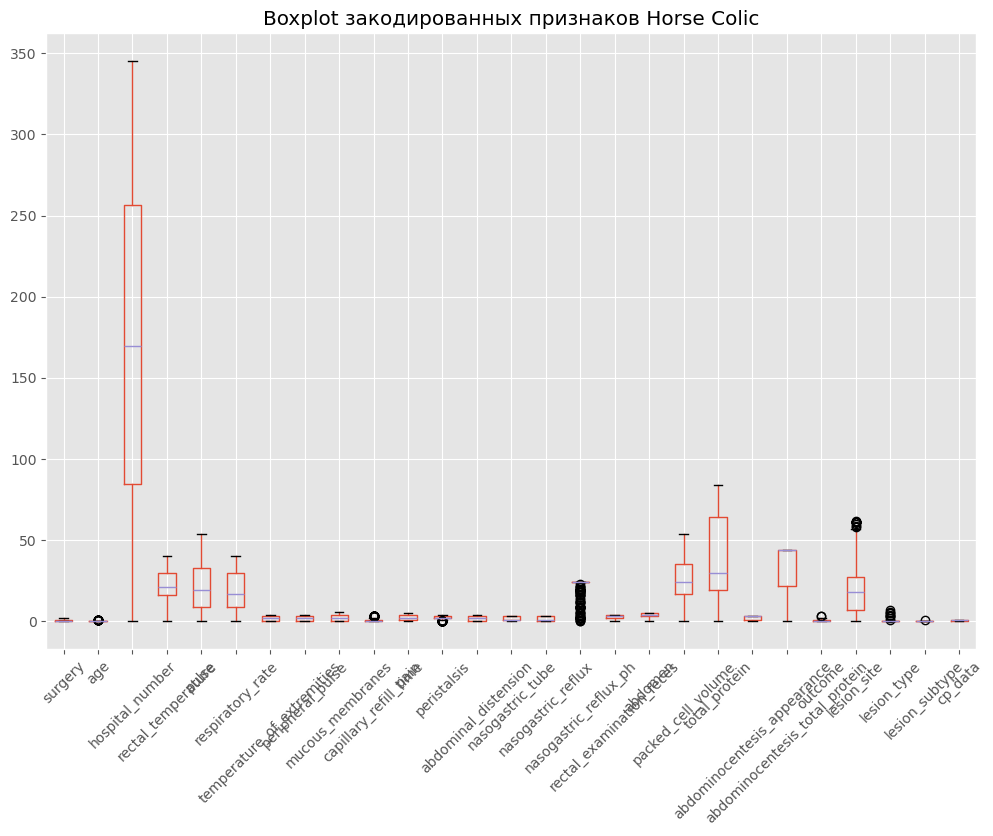

In [13]:
feature_cols = [col for col in df_encoded.columns if col != target_col]

df_encoded[feature_cols].boxplot()
plt.title('Boxplot закодированных признаков Horse Colic')
plt.xticks(rotation=45)
plt.show()

In [14]:
df_encoded[feature_cols].describe()

,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data
count,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,...,368.000000,368.000000,368.00000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000
mean,0.423913,0.076087,170.600543,23.236413,22.442935,20.048913,1.823370,1.646739,2.377717,0.581522,...,3.603261,27.375000,40.73913,2.076087,33.703804,0.540761,19.554348,0.105978,0.002717,0.663043
std,0.505742,0.265498,99.694606,10.100373,15.037175,12.647723,1.382569,1.572998,2.043463,0.936039,...,1.590226,13.470348,25.90619,1.121829,15.446022,0.751726,16.745971,0.698123,0.052129,0.473313
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,84.750000,16.000000,9.000000,9.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,17.000000,19.00000,1.000000,21.750000,0.000000,6.750000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,169.500000,21.000000,19.000000,17.000000,2.000000,2.000000,2.000000,0.000000,...,4.000000,24.000000,30.00000,3.000000,44.000000,0.000000,18.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,256.250000,30.000000,33.000000,30.000000,3.000000,3.000000,4.000000,1.000000,...,5.000000,35.250000,64.25000,3.000000,44.000000,1.000000,27.000000,0.000000,0.000000,1.000000
max,2.000000,1.000000,345.000000,40.000000,54.000000,40.000000,4.000000,4.000000,6.000000,3.000000,...,5.000000,54.000000,84.00000,3.000000,44.000000,3.000000,62.000000,7.000000,1.000000,1.000000


In [15]:
def remove_outliers_iqr(data, columns):
    df_result = data.copy()

    for column in columns:
        Q1 = df_result[column].quantile(0.25)
        Q3 = df_result[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = (df_result[column] < lower_bound) | (df_result[column] > upper_bound)
        print(column)
        print('Нижняя граница:', lower_bound)
        print('Верхняя граница:', upper_bound)
        print('Количество выбросов:', outliers.sum())
        print()

        df_result = df_result[~outliers]

    return df_result

df_clean = remove_outliers_iqr(df_encoded, feature_cols)

print('Данные до удаления выбросов:', df_encoded.shape)
print('Данные после удаления выбросов:', df_clean.shape)

df_clean.head()

surgery
Нижняя граница: -1.5
Верхняя граница: 2.5
Количество выбросов: 0

age
Нижняя граница: 0.0
Верхняя граница: 0.0
Количество выбросов: 28

hospital_number
Нижняя граница: -155.0
Верхняя граница: 471.0
Количество выбросов: 0

rectal_temperature
Нижняя граница: -3.875
Верхняя граница: 49.125
Количество выбросов: 0

pulse
Нижняя граница: -22.5
Верхняя граница: 61.5
Количество выбросов: 0

respiratory_rate
Нижняя граница: -19.875
Верхняя граница: 57.125
Количество выбросов: 0

temperature_of_extremities
Нижняя граница: -4.5
Верхняя граница: 7.5
Количество выбросов: 0

peripheral_pulse
Нижняя граница: -3.0
Верхняя граница: 5.0
Количество выбросов: 0

mucous_membranes
Нижняя граница: -6.0
Верхняя граница: 10.0
Количество выбросов: 0

capillary_refill_time
Нижняя граница: -1.5
Верхняя граница: 2.5
Количество выбросов: 30

pain
Нижняя граница: -3.5
Верхняя граница: 8.5
Количество выбросов: 0

peristalsis
Нижняя граница: 0.5
Верхняя граница: 4.5
Количество выбросов: 41

abdominal_distensio

,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
1,0,0,264,30,30,9,4,4,3,0,...,29,81,1,9,2,13,0,0,1,1
2,1,0,173,21,4,13,0,0,2,0,...,11,20,3,44,0,0,0,0,0,1
4,1,0,166,11,36,20,4,4,5,1,...,52,27,3,44,1,36,0,0,1,1
5,1,0,55,40,54,40,1,0,2,0,...,54,84,3,44,0,0,0,0,1,1
6,0,0,8,17,9,7,0,0,0,0,...,15,23,3,44,0,23,0,0,1,0


In [16]:
df_drop.to_csv('horse_colic_cleaned.csv', index=False)